In [98]:
import kagglehub
import numpy as np
import pandas
from rich.jupyter import display

# Download latest version
path = kagglehub.competition_download('bike-sharing-demand')

print("Path to competition files:", path)

Path to competition files: C:\Users\hurwa\.cache\kagglehub\competitions\bike-sharing-demand


In [99]:
from pathlib import Path

DATA_PATH = path
    # "C:/Users/hurwa/.cache/kagglehub/competitions/bike-sharing-demand"

file_names = []

for f in Path(DATA_PATH).iterdir():
    if f.is_file():
        print(f.name)
        file_names.append(f.name)

sampleSubmission.csv
test.csv
train.csv


In [100]:
import pandas as pd

raw_train = pd.read_csv(Path(DATA_PATH).joinpath("train.csv"))
raw_train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [101]:
raw_test = pd.read_csv(Path(DATA_PATH).joinpath("test.csv"))
raw_test.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014


# [Bike Sharing Demand](https://www.kaggle.com/competitions/bike-sharing-demand/data)
> 캐글에서 Competition으로 일어나고 있는 자전거 수요 예측 데이터셋입니다.

해당 데이터 경쟁의 대략적인 설명은 자전거 수요는 점점 늘어나고 있고 500개 이상의 자전거 대여 서비스가 있다고 합니다.

## 결과 목표치
> 다음과 같은 데이터 타입을 만들어야한다고 합니다.
| datetime | count |
|-----|---|
| 2011-01-20 00:00:00, | 0 |
| 2011-01-20 01:00:00, | 0 |
| 2011-01-20 02:00:00, | 0 |
| ... | ... |

해당 데이터셋의 목표는 RMSLE 점수를 낮게 책정되게 하는 것이라고 합니다.

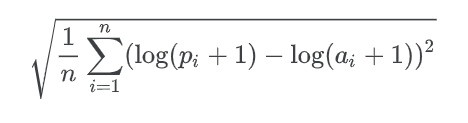

- `\\(n\\) is the number of hours in the test set`
- `\\(p_i\\) is your predicted count`
- `\\(a_i\\) is the actual count`
- `\\(\log(x)\\) is the natural logarithm`

## 데이터 분석 시작

In [102]:
# 일단 기본 데이터 확인해보기
def show_default_info(df: pd.DataFrame):
    print("shape:", df.shape)
    print()
    print(df.head())

    print("\n --- [결측치] --- \n")
    print("count:", df.isna().sum())
    print("ratio:", df.isna().mean())

    print("\n --- [describe] --- \n")
    print(df.describe(include="number"))
    print(df.describe(exclude="number"))

    print(df.nunique())

In [103]:
show_default_info(raw_train)

shape: (10886, 12)

              datetime  season  holiday  workingday  weather  temp   atemp  \
0  2011-01-01 00:00:00       1        0           0        1  9.84  14.395   
1  2011-01-01 01:00:00       1        0           0        1  9.02  13.635   
2  2011-01-01 02:00:00       1        0           0        1  9.02  13.635   
3  2011-01-01 03:00:00       1        0           0        1  9.84  14.395   
4  2011-01-01 04:00:00       1        0           0        1  9.84  14.395   

   humidity  windspeed  casual  registered  count  
0        81        0.0       3          13     16  
1        80        0.0       8          32     40  
2        80        0.0       5          27     32  
3        75        0.0       3          10     13  
4        75        0.0       0           1      1  

 --- [결측치] --- 

count: datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    

In [104]:
print((raw_train["casual"] + raw_train["registered"] == raw_train["count"]).mean())
print(raw_train["workingday"].unique())
print(raw_train["holiday"].unique())
print((raw_train["holiday"] & raw_train["workingday"]).mean()) #
print(((raw_train["holiday"]!=0).sum())) # 311 휴가
print((raw_train["workingday"]==0).sum()) # 3474 휴일
print(
    ((raw_train["workingday"]==0) | (raw_train["holiday"]==1)).sum() # 휴일에 휴가가 포함됨
) #
print(raw_train["weather"].unique())

1.0
[0 1]
[0 1]
0.0
311
3474
3474
[1 2 3 4]


# 데이터 확인 후
- 일단 컬럼은 12개 있고 데이터는 약 1.1만개
- datetime 타입이 있고 season은 int로 존재.
- workingday가 0, 1
- weather은 4가지
    - 1: `맑음` - Clear, Few clouds, Partly cloudy, Partly cloudy
    - 2: `습함` - Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
    - 3: `약간 안좋음` - Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
    - 4: `매우 안좋음` - Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
- temp는 49개
- count가 최종적으로 맞춰야하는 값. (데이터 누수 방지를 위해 빼야함)
- casual + registered == count임.
- atemp는 체감기온
# 해야할 일
1. 결측치 없으니 패스
2. datetime 시계열 및 주기형 등으로 보정
3. holiday, workingday, weather, season 범주형 또는 주기형으로 보정
4. holiday가 !workingday에 포함되는 것을 분리하기
5. 데이터 누수 값들 제거하기 (casual, registered, count)
6. 모델 선택 후 스케일링 확인해보기

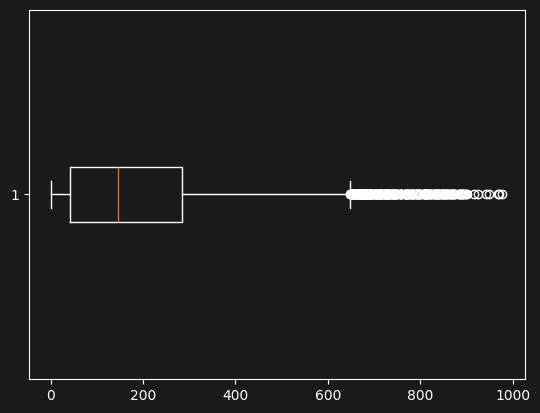

In [105]:
import matplotlib.pyplot as plt

plt.boxplot(raw_train["count"], orientation="horizontal")
plt.show()

# count는 아마 휴가날이나 직장이 바쁜날 등에 튀는 것으로 보임.

In [106]:
print(raw_train["holiday"].unique())
print(raw_train["workingday"].unique())

[0 1]
[0 1]


In [107]:
raw_train.dtypes

datetime          str
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object

In [108]:
print(raw_train["datetime"].min())
print(raw_train["datetime"].max())

2011-01-01 00:00:00
2012-12-19 23:00:00


In [109]:
numeric_cols = ["temp", "atemp", "humidity", "windspeed", "casual", "registered", "count"]
categorical_cols = ["season", "weather", "workingday", "holiday"]

In [110]:
from datetime import date
# pd.to_datetime(raw_train["datetime"]) - pd.Timestamp(2011, 1, 1)
pd.to_datetime(raw_train["datetime"]).dt.hour

0         0
1         1
2         2
3         3
4         4
         ..
10881    19
10882    20
10883    21
10884    22
10885    23
Name: datetime, Length: 10886, dtype: int32

In [111]:
train_df = raw_train.copy()
train_df[categorical_cols] = raw_train[categorical_cols].astype(str)
train_df[["year", "month", "day", "dayofweek", "elapsed_times", "hour"]] = pd.concat(
    (
        pd.to_datetime(raw_train["datetime"]).dt.year.astype(int),
        pd.to_datetime(raw_train["datetime"]).dt.month.astype(int),
        pd.to_datetime(raw_train["datetime"]).dt.day.astype(int),
        pd.to_datetime(raw_train["datetime"]).dt.dayofweek.astype(int),
        (pd.to_datetime(raw_train["datetime"]) - pd.Timestamp(2011, 1, 1)).dt.days.astype(int),
        pd.to_datetime(raw_train["datetime"]).dt.hour.astype(int)
    ), axis=1, ignore_index=True
)
train_df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,dayofweek,elapsed_times,hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,5,0,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,5,0,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,5,0,2
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,5,0,3
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,5,0,4


In [112]:
train_df.select_dtypes(include="number").columns

Index(['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered',
       'count', 'year', 'month', 'day', 'dayofweek', 'elapsed_times', 'hour'],
      dtype='str')

In [113]:
train_df[train_df.select_dtypes(include="number").columns].corr()

,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,dayofweek,elapsed_times,hour
temp,1.000000,0.984948,-0.064949,-0.017852,0.467097,0.318571,0.394454,0.061226,0.257589,0.015551,-0.038466,0.180785,0.145430
atemp,0.984948,1.000000,-0.043536,-0.057473,0.462067,0.314635,0.389784,0.058540,0.264173,0.011866,-0.040235,0.181629,0.140343
humidity,-0.064949,-0.043536,1.000000,-0.318607,-0.348187,-0.265458,-0.317371,-0.078606,0.204537,-0.011335,-0.026507,0.033236,-0.278011
windspeed,-0.017852,-0.057473,-0.318607,1.000000,0.092276,0.091052,0.101369,-0.015221,-0.150192,0.036157,-0.024804,-0.087088,0.146631
casual,0.467097,0.462067,-0.348187,0.092276,1.000000,0.497250,0.690414,0.145241,0.092722,0.014109,0.246959,0.172313,0.302045
registered,0.318571,0.314635,-0.265458,0.091052,0.497250,1.000000,0.970948,0.264265,0.169451,0.019111,-0.084427,0.314356,0.380540
count,0.394454,0.389784,-0.317371,0.101369,0.690414,0.970948,1.000000,0.260403,0.166862,0.019826,-0.002283,0.309636,0.400601
year,0.061226,0.058540,-0.078606,-0.015221,0.145241,0.264265,0.260403,1.000000,-0.004932,0.001800,-0.003785,0.866568,-0.004234
month,0.257589,0.264173,0.204537,-0.150192,0.092722,0.169451,0.166862,-0.004932,1.000000,0.001974,-0.002266,0.494092,-0.006818
day,0.015551,0.011866,-0.011335,0.036157,0.014109,0.019111,0.019826,0.001800,0.001974,1.000000,-0.011070,0.028561,0.001132


In [114]:
train_df["count"].dtype

dtype('int64')

In [115]:
# count중에서 기하급수적으로 높은 부분 원인 찾아보기
# (train_df["count"] >
high_count_df = train_df[train_df["count"] > train_df["count"].quantile(0.9)][
    train_df.drop(columns=["season", "holiday"]).columns
].sort_values(by=["count"], ascending=False)

In [116]:
from IPython.display import display

print("high count df working day ratio")
print(high_count_df["workingday"].value_counts(normalize=True))

print("train df working day ratio")
print(train_df["workingday"].value_counts(normalize=True))

high count df working day ratio
workingday
1    0.681985
0    0.318015
Name: proportion, dtype: float64
train df working day ratio
workingday
1    0.680875
0    0.319125
Name: proportion, dtype: float64


In [117]:
# holiday가 아닌날에 살짝 더 많긴 하지만 큰 차이는 없어보임
train_df.groupby("holiday")["count"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
holiday,,,,
0,191.741655,145.0,1,977
1,185.877814,133.0,1,712


In [118]:
train_df.groupby("weather")["count"].agg(["mean", "median", "min", "max", "count"])
# weather이 좋을 떄 수요가 높은편이긴 한데 4의 경우에는 그냥 특별한 날에 여러명이 타고가야했던 날이 있었던거같고. 이걸 어떻게 해석해야하려나

,mean,median,min,max,count
weather,,,,,
1,205.236791,161.0,1,977,7192
2,178.955540,134.0,1,890,2834
3,118.846333,71.0,1,891,859
4,164.000000,164.0,164,164,1


In [119]:
train_df.groupby("season")["count"].agg(["mean", "median", "min", "max", "count"])
# 이건 확실히 가을쪽이 약간 우세하긴 한데 수요가 있던 날은 고르게 분포되어있긴 하다. 오히려 봄에 수요가 적은 느낌인가?

,mean,median,min,max,count
season,,,,,
1,116.343261,78.0,1,801,2686
2,215.251372,172.0,1,873,2733
3,234.417124,195.0,1,977,2733
4,198.988296,161.0,1,948,2734


In [120]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   datetime       10886 non-null  str    
 1   season         10886 non-null  str    
 2   holiday        10886 non-null  str    
 3   workingday     10886 non-null  str    
 4   weather        10886 non-null  str    
 5   temp           10886 non-null  float64
 6   atemp          10886 non-null  float64
 7   humidity       10886 non-null  int64  
 8   windspeed      10886 non-null  float64
 9   casual         10886 non-null  int64  
 10  registered     10886 non-null  int64  
 11  count          10886 non-null  int64  
 12  year           10886 non-null  int64  
 13  month          10886 non-null  int64  
 14  day            10886 non-null  int64  
 15  dayofweek      10886 non-null  int64  
 16  elapsed_times  10886 non-null  int64  
 17  hour           10886 non-null  int64  
dtypes: float64(3), in

# train_df 를 정리할 순서
> 최종 목표는 `datetime, count`를 맞추는 것이다.
1. datetime는 제거하기 (하지만 최종 출력에는 datetime가 들어가야 하기 때문에 아마 인덱스로 바꾸거나 파이프라인으로 만들어야할 것 같다.)
2. season은 원핫 인코딩
3. holiday도 원핫 인코딩
4. workingday도 원핫
5. temp, atemp, humidity, windspeed는 그대로 수치형으로
6. casual, registered는 누수이므로 삭제, count는 target 시리즈로 빼주기
7. 2년짜리 데이터셋이기 때문에 year, day는 삭제하고 elapsed_times만 남기기
8. month, dayofweek, hour는 시계열로 sin/cos 2개 열로 나눠주기

# 실제 데이터 확인 후 다시 든 생각
> 일단 모델은 결정트리 기반의 `랜덤 포레스트 (앙상블)`과 `Gradient Boosting Tree (부스팅)` 모델을 사용해보려 한다. 이에 따라 스케일링은 필요하지 않으며 테스트 데이터에는 `datetime`컬럼이 있고, `registered`, `casual` 컬럼이 없으며 `count`만을 맞추면 되는 문제이기 때문에 전처리 후 파이프라이닝이후 출력하느 모델만 만들면 된다. 따라서 최초 `raw_train` 데이터에서 3컬럼을 제거하고 `count` 컬럼을 `y_train`으로 만들어 작업을 하면 될 것 같다. 당연히 미래 예측이기 때문에 `Time Series validation` 전략을 이용하면 될 것 같다.

In [121]:
raw_train

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


# 작업 시작

In [122]:
X = raw_train.drop(
    # 3개의 쓰지 않는 컬럼들 제거
    columns=["count", "casual", "registered"]
).sort_values("datetime").reset_index(drop=True)
# 예측할 목표인 컬럼을 y로 설정
y = raw_train["count"]

## 참고로 test_train_split로 나누지 않고 시계열 방식으로 나눌 예정

In [123]:
def datetime_features(df):
    """datetime[YYYY-mm-dd HH:mm:ss] 컬럼을 | year | month | dayofweek | hour | 로 나누기"""

    new_df = df.copy()

    datetime = pd.to_datetime(new_df["datetime"])

    new_df["year"] = datetime.dt.year
    new_df["month"] = datetime.dt.month
    new_df["dayofweek"] = datetime.dt.dayofweek
    new_df["hour"] = datetime.dt.hour

    return new_df.drop(columns=["datetime"])

In [124]:
from sklearn.preprocessing import FunctionTransformer

datetime_transformer = FunctionTransformer(
    # FunctionTransformer을 통해 sklearn Transformer 계열로 바꿔주기
    datetime_features,
    validate=False
)

# 데이터 컬럼별로 나눠주기

In [125]:
# 범주형 데이터들 (숫자 타입 이여도 원핫 인코딩 해줌)
categorical_cols = [
    "season",
    "weather"
]

# 숫자인거
numeric_cols = [
    "holiday",
    "workingday",
    "temp",
    "atemp",
    "humidity",
    "windspeed",
    "year",
    "month",
    "dayofweek",
    "hour"
]

# 데이터 컬럼 변환 transformer

In [126]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

column_transformer = ColumnTransformer(
    transformers=[
        (   # 범주형은 원핫 인코딩하기
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        ),
        (
            "num",
            "passthrough", # 변환없이 그대로
            numeric_cols
        )
    ]
)

In [127]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

baseline_model = Pipeline(
    steps=[
        (
            "datetime",
            datetime_transformer
        ),
        (
            "columns",
            column_transformer
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=50,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [128]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import root_mean_squared_log_error
from sklearn.base import clone

tscv = TimeSeriesSplit(n_splits=10)

scores = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X), start=1):
    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    print(f"train date: {X_train["datetime"].min()} ~ {X_train["datetime"].max()}")
    print(f"valid date: {X_val["datetime"].min()} ~ {X_val["datetime"].max()}")

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    # 매 fold마다 새로운 모델
    model = clone(baseline_model)

    # 과거 데이터로 학습
    model.fit(X_train, y_train)

    # 미래 구간 예측
    pred = model.predict(X_val)

    # RMSLE
    score = root_mean_squared_log_error(y_val, pred)

    scores.append(score)

    print(f"Fold {fold} RSMLE: {score:.4f}")

import numpy as np

print("평균 RMSLE:", np.mean(scores))

train date: 2011-01-01 00:00:00 ~ 2011-03-05 22:00:00
valid date: 2011-03-05 23:00:00 ~ 2011-05-09 14:00:00
Fold 1 RSMLE: 0.6156
train date: 2011-01-01 00:00:00 ~ 2011-05-09 14:00:00
valid date: 2011-05-09 15:00:00 ~ 2011-07-12 19:00:00
Fold 2 RSMLE: 0.5020
train date: 2011-01-01 00:00:00 ~ 2011-07-12 19:00:00
valid date: 2011-07-12 20:00:00 ~ 2011-09-16 03:00:00
Fold 3 RSMLE: 0.3824
train date: 2011-01-01 00:00:00 ~ 2011-09-16 03:00:00
valid date: 2011-09-16 04:00:00 ~ 2011-11-19 09:00:00
Fold 4 RSMLE: 0.3877
train date: 2011-01-01 00:00:00 ~ 2011-11-19 09:00:00
valid date: 2011-11-19 10:00:00 ~ 2012-02-03 17:00:00
Fold 5 RSMLE: 0.5730
train date: 2011-01-01 00:00:00 ~ 2012-02-03 17:00:00
valid date: 2012-02-03 18:00:00 ~ 2012-04-07 01:00:00
Fold 6 RSMLE: 0.4594
train date: 2011-01-01 00:00:00 ~ 2012-04-07 01:00:00
valid date: 2012-04-07 02:00:00 ~ 2012-06-10 07:00:00
Fold 7 RSMLE: 0.3842
train date: 2011-01-01 00:00:00 ~ 2012-06-10 07:00:00
valid date: 2012-06-10 08:00:00 ~ 2012-08-1

# Y값을 log로 설정하여 예측해보기

In [129]:
# 주기형 인코딩
scores = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X), start=1):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = clone(baseline_model)

    # 핵심: target을 로그 변환해서 학습
    y_train_log = np.log1p(y_train)

    model.fit(X_train, y_train_log)

    # 모델의 예측값도 log(count) 형태
    pred_log = model.predict(X_val)

    # 원래 count 스케일로 복원
    pred = np.expm1(pred_log)

    # 혹시 음수가 생기는 모델을 대비
    pred = np.clip(pred, 0, None)

    score = root_mean_squared_log_error(
        y_val,
        pred
    )

    scores.append(score)

    print(f"Fold {fold}: {score:.4f}")


print("평균 RMSLE:", np.mean(scores))

Fold 1: 0.6239
Fold 2: 0.4574
Fold 3: 0.3379
Fold 4: 0.3859
Fold 5: 0.6286
Fold 6: 0.4787
Fold 7: 0.3733
Fold 8: 0.2920
Fold 9: 0.3430
Fold 10: 0.4095
평균 RMSLE: 0.4330223590145902


# 랜덤포레스트이기 때문에 주기형 인코딩 등은 필수가 아니다
# 따라서 이런저런 가설을 실험해 보는 것이 좋다.

In [130]:
print(baseline_model)

Pipeline(steps=[('datetime',
                 FunctionTransformer(func=<function datetime_features at 0x000001E06819B600>)),
                ('columns',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['season', 'weather']),
                                                 ('num', 'passthrough',
                                                  ['holiday', 'workingday',
                                                   'temp', 'atemp', 'humidity',
                                                   'windspeed', 'year', 'month',
                                                   'dayofweek', 'hour'])])),
                ('model',
                 RandomForestRegressor(n_estimators=50, n_jobs=-1,
                                       random_state=42))])


In [131]:
def datetime_features_cyclical(df):
    new_df = df.copy()

    datetime = pd.to_datetime(new_df["datetime"])

    new_df["year"] = datetime.dt.year
    new_df["month"] = datetime.dt.month
    new_df["dayofweek"] = datetime.dt.dayofweek
    new_df["hour"] = datetime.dt.hour

    # 새로운 실험
    new_df["hour_sin"] = np.sin(
        2 * np.pi * new_df["hour"] / 24
    )

    new_df["hour_cos"] = np.cos(
        2 * np.pi * new_df["hour"] / 24
    )

    return new_df.drop(columns=["datetime"])

In [132]:
from sklearn.preprocessing import FunctionTransformer

datetime_cyclical_transformer = FunctionTransformer(
    datetime_features_cyclical,
    validate=False
)

In [140]:
numeric_cols_cyclical = [
    "holiday",
    "workingday",
    "temp",
    "atemp",
    "humidity",
    "windspeed",
    "year",
    "month",
    "dayofweek",
    # "hour",

    # 추가된 컬럼
    "hour_sin",
    "hour_cos"
]

In [141]:
column_transformer_cyclical = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        ),
        (
            "num",
            "passthrough",
            numeric_cols_cyclical
        )
    ]
)

In [142]:
hour_cyclical_model = Pipeline(
    steps=[
        (
            "datetime",
            datetime_cyclical_transformer
        ),
        (
            "columns",
            column_transformer_cyclical
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=50,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [143]:
tscv = TimeSeriesSplit(n_splits=10)

scores = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X), start=1):
    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    print(f"train date: {X_train["datetime"].min()} ~ {X_train["datetime"].max()}")
    print(f"valid date: {X_val["datetime"].min()} ~ {X_val["datetime"].max()}")

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    # 매 fold마다 새로운 모델
    model = clone(hour_cyclical_model)

    # 과거 데이터로 학습
    model.fit(X_train, y_train)

    # 미래 구간 예측
    pred = model.predict(X_val)

    # RMSLE
    score = root_mean_squared_log_error(y_val, pred)

    scores.append(score)

    print(f"Fold {fold} RSMLE: {score:.4f}")

import numpy as np

print("평균 RMSLE:", np.mean(scores))

train date: 2011-01-01 00:00:00 ~ 2011-03-05 22:00:00
valid date: 2011-03-05 23:00:00 ~ 2011-05-09 14:00:00
Fold 1 RSMLE: 0.6188
train date: 2011-01-01 00:00:00 ~ 2011-05-09 14:00:00
valid date: 2011-05-09 15:00:00 ~ 2011-07-12 19:00:00
Fold 2 RSMLE: 0.5682
train date: 2011-01-01 00:00:00 ~ 2011-07-12 19:00:00
valid date: 2011-07-12 20:00:00 ~ 2011-09-16 03:00:00
Fold 3 RSMLE: 0.3817
train date: 2011-01-01 00:00:00 ~ 2011-09-16 03:00:00
valid date: 2011-09-16 04:00:00 ~ 2011-11-19 09:00:00
Fold 4 RSMLE: 0.3881
train date: 2011-01-01 00:00:00 ~ 2011-11-19 09:00:00
valid date: 2011-11-19 10:00:00 ~ 2012-02-03 17:00:00
Fold 5 RSMLE: 0.5729
train date: 2011-01-01 00:00:00 ~ 2012-02-03 17:00:00
valid date: 2012-02-03 18:00:00 ~ 2012-04-07 01:00:00
Fold 6 RSMLE: 0.4321
train date: 2011-01-01 00:00:00 ~ 2012-04-07 01:00:00
valid date: 2012-04-07 02:00:00 ~ 2012-06-10 07:00:00
Fold 7 RSMLE: 0.3766
train date: 2011-01-01 00:00:00 ~ 2012-06-10 07:00:00
valid date: 2012-06-10 08:00:00 ~ 2012-08-1